## Import Libraries

In [32]:
import pennylane as qml
# from pennylane import numpy as np

import numpy as np
np.bool8 = np.bool_

import gym
import collections
import random

import torch
import matplotlib.pyplot as plt
import torch.optim as optim

from datetime import datetime
import os
from torch.utils.tensorboard import SummaryWriter
import imageio

now     = datetime.now()
f_dir = f'tensorboard/QRL/Cartpole/QRL_DQN_nlayer_3_{now.date()}_{now.hour}h_{now.minute}m_{now.second}s/{now.date()}_{now.hour}h_{now.minute}m_{now.second}s'
os.makedirs(f_dir, exist_ok=True)
writer = SummaryWriter(f_dir)

## Hyperparameter Settings

In [33]:
#Hyperparameters
learning_rate = 0.0005
gamma         = 0.98
buffer_limit  = 50000
batch_size    = 32

## Replay Buffer

In [34]:
import collections
import random
import torch

class ReplayBuffer():
    def __init__(self):
        # collections.deque를 사용하여 양방향 큐(queue) 형태의 버퍼를 생성합니다.
        # 이전 질문에 나왔던 buffer_limit이 여기에 사용됩니다.
        # maxlen을 설정해두면, 버퍼가 가득 찼을 때 새로운 데이터가 들어오면
        # 가장 오래된(가장 먼저 들어온) 데이터가 자동으로 삭제되어 메모리를 효율적으로 관리합니다.
        self.buffer = collections.deque(maxlen=buffer_limit)
    
    def put(self, transition):
        # 에이전트가 환경과 한 스텝 상호작용하고 얻은 경험 하나(transition)를 버퍼에 추가합니다.
        # transition은 일반적으로 (현재 상태, 행동, 보상, 다음 상태, 종료 여부)의 튜플 형태입니다.
        self.buffer.append(transition)
    
    def sample(self, n):
        # 버퍼에 저장된 과거의 경험 중 n개(미니 배치 사이즈)를 무작위로 추출합니다.
        # 순차적인 데이터를 무작위로 섞어서 뽑는 이유는 데이터 간의 시간적 상관관계(correlation)를 
        # 깨뜨려 신경망 학습을 안정화하기 위함입니다.
        mini_batch = random.sample(self.buffer, n)
        
        # 무작위로 뽑은 n개의 경험을 각각의 요소별로 분리하기 위해 빈 리스트를 준비합니다.
        s_lst, a_lst, r_lst, s_prime_lst, done_mask_lst = [], [], [], [], []
        
        for transition in mini_batch:
            # 튜플 형태의 transition의 압축을 풀어 각각의 변수에 할당합니다.
            # s: 현재 상태, a: 행동, r: 보상, s_prime: 다음 상태, done_mask: 에피소드 종료 여부
            s, a, r, s_prime, done_mask = transition
            
            # 각각의 리스트에 값들을 모아줍니다.
            s_lst.append(s)
            s_prime_lst.append(s_prime)
            
            # 주의: a, r, done_mask를 리스트 형태로 한 번 더 감싸서([]) 넣는 이유는
            # 나중에 파이토치(PyTorch) 텐서로 변환할 때 배열의 차원(Shape)을 맞추기 위해서입니다.
            # (예: 크기가 32인 배치의 경우, shape을 (32,)가 아닌 (32, 1)의 형태인 열벡터로 만들기 위함)
            a_lst.append([a])
            r_lst.append([r])
            done_mask_lst.append([done_mask])

        # 모아둔 리스트들을 파이토치의 텐서(Tensor) 객체로 변환하여 반환합니다.
        # 상태(State) 값들은 보통 신경망의 입력으로 들어가므로 명시적으로 실수형(torch.float)으로 지정합니다.
        return torch.tensor(s_lst, dtype=torch.float), torch.tensor(a_lst), \
               torch.tensor(r_lst), torch.tensor(s_prime_lst, dtype=torch.float), \
               torch.tensor(done_mask_lst)
    
    def size(self):
        # 현재 버퍼에 저장되어 있는 데이터의 총 개수를 반환합니다.
        # 학습 초기에는 버퍼가 덜 찼을 수 있으므로, 버퍼에 일정량 이상 데이터가 쌓였는지 확인할 때 주로 사용합니다.
        return len(self.buffer)

## Neural Network Architecture

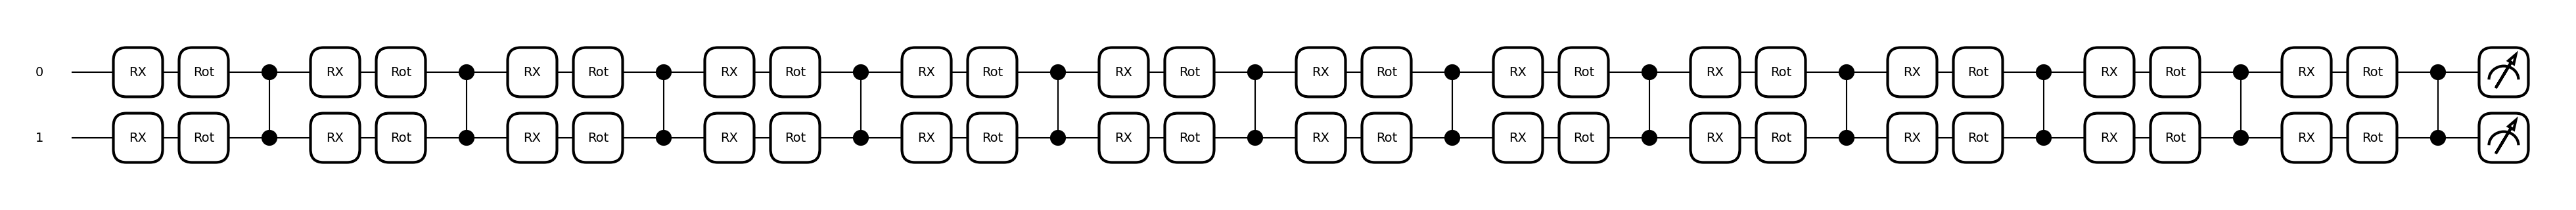

In [35]:
# 1. 양자 디바이스 설정
# 2개의 큐비트(wires=2)를 사용하는 PennyLane의 기본 상태 벡터 시뮬레이터를 생성합니다.
dev_2 = qml.device("default.qubit", wires=2)

# 2. QNode 데코레이터
# 아래의 파이썬 함수를 양자 노드(QNode)로 변환하여, 위에서 만든 디바이스(dev_2)에서 실행되도록 연결합니다.
@qml.qnode(dev_2)
def qnode_2(inputs, weights):
    '''
    여기서는 input이 (layer, x_dim, qubit, 3) 
    (참고: 주석의 설명과 실제 아래에서 넣어주는 더미 데이터의 차원이 조금 섞여 있지만, 
    일반적으로 inputs는 데이터(feature), weights는 학습할 파라미터 텐서를 의미합니다.)
    '''
    # 신경망의 은닉층(Hidden Layer)을 여러 개 쌓듯이, 양자 회로의 레이어(층)를 반복해서 쌓습니다.
    for p in weights: 
        
        # 은닉층 내부 설정 (inner-wire setup)
        # 데이터의 특성(feature) 차원 수(x_dim)만큼 반복하며 연산을 수행합니다.
        for i, param in enumerate(p):
            
            # 각 큐비트(0번, 1번)에 대해 개별적으로 게이트를 적용합니다.
            for j, qubit_param in enumerate(param):
                
                # [데이터 인코딩 부분]
                # 고전적인 입력 데이터를 양자 상태로 변환하기 위해 X축 기준 회전(RX) 게이트를 사용합니다.
                # 데이터 값이 각도로 치환되어 큐비트의 상태를 변화시킵니다.
                qml.RX(inputs[:, i], wires=j)           
                
                # [파라미터 연산 부분 (신경망의 가중치)]
                # qml.Rot는 임의의 3차원 회전(RZ-RY-RZ)을 수행하는 게이트입니다.
                # *qubit_param은 3개의 파라미터가 담긴 리스트나 배열을 언패킹하여 각각의 회전 각도로 넣어줍니다.
                qml.Rot(*qubit_param, wires=j)
            
            # 큐비트 간 상호작용 설정 (inter-wire setup)
            # 두 큐비트를 얽힘(Entanglement) 상태로 만드는 제어-Z(Controlled-Z) 게이트입니다.
            # 이 얽힘 연산이 있어야 큐비트들이 독립적으로 동작하지 않고, 복잡한 비선형적 관계를 학습할 수 있습니다.
            qml.CZ(wires=[0, 1])
            
    # 모든 연산이 끝난 후, 각 큐비트(0, 1)의 Z축 기준 기댓값(Expectation Value)을 측정하여 반환합니다.
    # 이 측정값들이 고전적 신경망의 출력(Output) 노드 값처럼 사용됩니다. (값의 범위: -1 ~ 1)
    return [qml.expval(qml.Z(wires=i)) for i in range(2)]
    
# 3. 모델 하이퍼파라미터 설정
n_layers = 3          # 회로를 몇 층으로 깊게 쌓을 것인가 (깊을수록 표현력이 높아지지만 학습이 어려워짐)
x_dim = 4             # 입력 데이터의 특성(Feature) 개수
n_param_per_gate = 3  # qml.Rot 게이트에 필요한 파라미터 개수 (phi, theta, omega 3개)

# 가중치 텐서의 형태를 딕셔너리로 정의합니다. PennyLane 내부 최적화기를 사용할 때 템플릿으로 쓰입니다.
weight_shapes = {"weights": (n_layers, x_dim, 2, n_param_per_gate)}

# 4. 양자 회로 시각화 (Drawing)
# qnode_2 함수에 0으로 채워진 더미 데이터(np.zeros)를 통과시키면서, 
# Matplotlib을 이용해 시각적인 양자 회로도(Circuit Diagram)를 그려냅니다.
qml.draw_mpl(qnode_2)(np.zeros((1, 4, 2, 3)), np.zeros((n_layers, x_dim, 2, n_param_per_gate)))

# 그려진 회로도를 화면에 띄웁니다.
plt.show()

In [36]:
def create_model(n_qubit, n_layer, x_dim):
    # 양자 회로 내부에서 최적화 알고리즘을 통해 업데이트할 가중치 텐서의 구조를 딕셔너리로 정의합니다.
    # 이전 질문의 코드와 연결해 보면 각각 층의 개수, 데이터 특성의 차원, 큐비트 개수, 
    # 그리고 qml.Rot 게이트에 필요한 3개의 회전 파라미터를 차례대로 의미합니다.
    weight_shapes = {"weights": (n_layer, x_dim, n_qubit, 3)}
    
    # PennyLane에서 제공하는 TorchLayer 클래스를 호출하여 양자 노드를 감싸줍니다.
    # 미리 만들어둔 qnode와 가중치 구조인 weight_shapes를 인자로 넘겨주면 
    # 해당 양자 회로 전체가 파이토치의 일반적인 신경망 계층처럼 작동하는 객체로 반환됩니다.
    return qml.qnn.TorchLayer(qnode, weight_shapes)

In [37]:
def sample_action(act, epsilon):
    # 0.0에서 1.0 사이의 임의의 실수를 하나 생성하여 coin 변수에 저장합니다.
    coin = random.random()
    
    # 동전 던지기 결과인 coin 값이 탐험 확률을 나타내는 epsilon 값보다 작은지 확인합니다.
    if coin < epsilon:
        # 조건이 참이라면 무작위 탐색을 수행하는 단계에 진입합니다.
        # 현재 환경에서 가능한 행동이 0과 1 두 가지라고 가정할 때 둘 중 하나를 무작위로 선택하여 반환합니다.
        return random.randint(0,1)
    else : 
        # 조건이 거짓이라면 학습된 지식을 활용하는 단계에 진입합니다.
        # 신경망이 예측한 행동 가치들인 act 텐서에서 가장 값이 큰 행동의 인덱스를 찾아냅니다.
        # item 함수는 파이토치 텐서에 담긴 단일 값을 일반적인 파이썬 숫자로 추출해 주는 역할을 합니다.
        return act.argmax().item()

In [38]:
import torch.nn.functional as F

def train(q, q_target, memory, optimizer):
    # 버퍼에서 데이터를 뽑아 신경망을 업데이트하는 과정을 10번 반복합니다.
    for i in range(10):
        # 리플레이 버퍼에서 배치 사이즈만큼의 과거 경험 데이터를 무작위로 추출합니다.
        # 상태, 행동, 보상, 다음 상태, 종료 여부 데이터를 각각의 변수에 나누어 담습니다.
        s, a, r, s_prime, done_mask = memory.sample(batch_size)

        # 현재 상태를 메인 신경망인 q에 통과시켜 모든 가능한 행동들의 가치값을 계산합니다.
        q_out = q(s)
        
        # 메인 신경망이 출력한 여러 행동 가치값 중에서 에이전트가 실제로 취했던 행동의 가치값만 골라냅니다.
        # gather 함수는 주어진 인덱스인 a에 해당하는 값들만 텐서에서 추출하는 역할을 합니다.
        q_a = q_out.gather(1,a)
        
        # 다음 상태를 타겟 네트워크에 통과시켜 다음 상태에서 얻을 수 있는 최대 가치값을 찾습니다.
        # max 함수를 통해 최댓값을 찾고 unsqueeze 함수를 통해 텐서의 차원을 계산하기 좋게 맞추어 줍니다.
        max_q_prime = q_target(s_prime).max(1)[0].unsqueeze(1)
        
        # 에이전트가 학습해야 할 정답지인 타겟값을 계산합니다.
        # 즉각적으로 받은 보상에 미래의 최대 기대 보상을 할인율 감마와 곱하여 더해주는 벨만 최적 방정식 원리를 사용합니다.
        # 에피소드가 끝났다면 done_mask 값이 0이 되어 미래 보상을 무시하도록 만듭니다.
        target = r + gamma * max_q_prime * done_mask
        
        # 에이전트의 현재 예측값인 q_a와 목표값인 target 사이의 오차를 계산합니다.
        # 극단적인 오차값에 덜 민감한 smooth L1 손실 함수를 사용하여 학습을 안정화합니다.
        loss = F.smooth_l1_loss(q_a, target)
        
        # 이전 단계에서 파이토치 내부에 누적된 기울기 값들을 0으로 초기화합니다.
        optimizer.zero_grad()
        
        # 오차 값을 바탕으로 신경망 내부의 모든 가중치에 대한 기울기를 역전파로 계산합니다.
        loss.backward()
        
        # 계산된 기울기를 사용하여 실제로 메인 신경망의 가중치를 업데이트합니다.
        optimizer.step()

In [39]:
def save_gif(model, filename):
    render_env = gym.make('CartPole-v1', render_mode='rgb_array')
    s, _ = render_env.reset()
    done = False
    score = 0
    frames = []

    while not done:
        frame = render_env.render()
        frames.append(frame)
        
        # 모델이 GPU에 올라가 있으므로 입력되는 상태 텐서도 to("cuda")를 통해 GPU로 보내줍니다.
        state_tensor = torch.tensor(s).float().view(1, -1).to("cuda")
        a = model(state_tensor)
        action = a.argmax().item()
        
        s, r, done, truncated, info = render_env.step(action)
        score += r
        
        if score > 499:
            break
            
    render_env.close()
    
    imageio.mimsave(filename, frames, fps=30)
    print(f"{filename} 파일 저장 완료, 달성 점수: {score}")

## Driving Code

In [ ]:
# 앞서 구성한 양자 회로의 구조에 맞추어 모델 하이퍼파라미터를 설정합니다.
n_layers = 3
x_dim = 4
n_param_per_gate = 3
weight_shapes = {"weights": (n_layers, x_dim, 2, n_param_per_gate)}

# 막대가 쓰러지지 않게 카트를 움직이는 CartPole-v1 환경을 생성합니다.
env = gym.make('CartPole-v1')
# env = gym.make('CartPole-v1', render_mode='human')

# 양자 노드를 파이토치 레이어로 변환하고 GPU(cuda) 메모리에 올립니다.
q = qml.qnn.TorchLayer(qnode_2, weight_shapes).to("cuda")
q_target = qml.qnn.TorchLayer(qnode_2, weight_shapes).to("cuda")

# 학습 초기화를 위해 타겟 네트워크의 가중치를 메인 네트워크와 동일하게 맞춥니다.
q_target.load_state_dict(q.state_dict())

# 경험을 저장할 공간인 리플레이 버퍼 객체를 생성합니다.
memory = ReplayBuffer()

# 진행 상황을 출력할 에피소드 간격과 초기 점수를 설정합니다.
print_interval = 20
score = 0.0  

# 최적화 알고리즘으로 아담(Adam)을 사용하며 메인 네트워크의 파라미터를 학습 대상으로 지정합니다.
optimizer = optim.Adam(q.parameters(), lr=learning_rate)

save_gif(q, 'before_training.gif')

# 총 10000번의 에피소드를 반복하며 에이전트를 훈련시킵니다.
for n_epi in range(10000):
    # 입실론 값을 에피소드가 진행됨에 따라 8%에서 1%로 서서히 감소시켜 탐험 비율을 줄입니다.
    epsilon = max(0.01, 0.08 - 0.01*(n_epi/200)) 
    
    # 새로운 에피소드를 시작하기 위해 환경을 초기화하고 첫 상태를 받아옵니다.
    s, _ = env.reset()
    done = False

    # 하나의 에피소드가 끝날 때까지 스텝을 반복합니다.
    while not done:
        # env.render()
        
        # 현재 상태를 파이토치 텐서로 변환한 뒤 양자 신경망에 입력하여 행동 가치들을 계산합니다.
        a = q(torch.tensor(s).float().view(1, -1))
        
        # 입실론 탐욕 전략 함수를 거쳐 실제로 취할 행동을 결정합니다.
        a = sample_action(a, epsilon)      
        
        # 결정한 행동을 환경에 가하고 다음 상태와 보상 그리고 종료 여부 등을 반환받습니다.
        s_prime, r, done, truncated, info = env.step(a)

        # 에피소드가 끝났다면 0을 주고 계속 진행 중이라면 1을 주어 미래 보상 계산에 사용할 마스크를 만듭니다.
        done_mask = 0.0 if done else 1.0
        
        # 학습을 안정적으로 만들기 위해 보상을 100으로 나누어 작게 만든 뒤 버퍼에 저장합니다.
        memory.put((s,a,r/100.0,s_prime, done_mask))
        s = s_prime

        # 에피소드의 총점에 현재 얻은 보상을 누적합니다.
        score += r
        
        # 환경이 종료 신호를 보내면 반복문을 탈출하여 에피소드를 마칩니다.
        if done:
            break

        # 목표 점수인 500점을 초과하면 더 이상 진행하지 않고 해당 에피소드를 종료합니다.
        if score > 499:
            print('over 500')
            break

    # 리플레이 버퍼에 데이터가 2000개 이상 충분히 쌓였다면 메인 네트워크 학습을 진행합니다.
    if memory.size()>2000:
        train(q, q_target, memory, optimizer)

    # 20번의 에피소드마다 한 번씩 타겟 네트워크의 가중치를 메인 네트워크의 최신 가중치로 덮어씌웁니다.
    if n_epi%print_interval==0 and n_epi!=0:
        q_target.load_state_dict(q.state_dict())

    # 매 에피소드가 끝날 때마다 학습 진행 척도들을 화면에 출력합니다.
    print("n_episode :{}, score : {:.1f}, n_buffer : {}, eps : {:.1f}%".format(
                                                    n_epi, score, memory.size(), epsilon*100))
    
    # 텐서보드 시각화를 위해 에피소드별 점수를 기록으로 남깁니다.
    writer.add_scalar('Reward', score, n_epi)
    score = 0.0

# 모든 훈련 과정이 끝나면 환경을 닫고 리소스를 반환합니다.
env.close()

save_gif(q, 'after_training.gif')

before_training.gif 파일 저장 완료, 달성 점수: 9.0
n_episode :0, score : 9.0, n_buffer : 9, eps : 8.0%
n_episode :1, score : 10.0, n_buffer : 19, eps : 8.0%
n_episode :2, score : 11.0, n_buffer : 30, eps : 8.0%
n_episode :3, score : 15.0, n_buffer : 45, eps : 8.0%
n_episode :4, score : 12.0, n_buffer : 57, eps : 8.0%
n_episode :5, score : 9.0, n_buffer : 66, eps : 8.0%
n_episode :6, score : 10.0, n_buffer : 76, eps : 8.0%


qiskit으로 그린 해당 Quantum Circuit

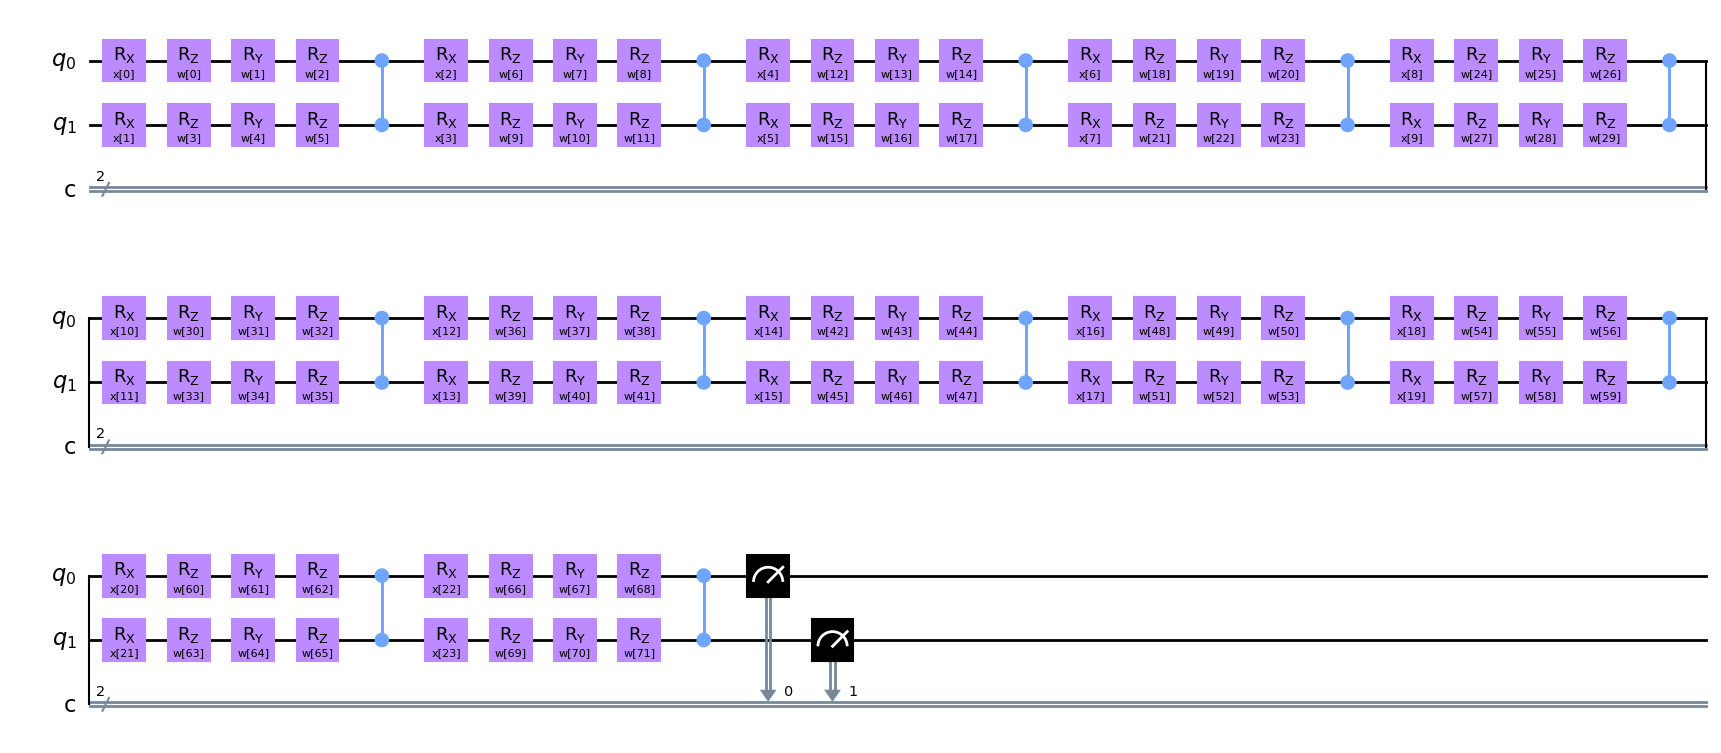